# 03c — FINAL M2A Macro-Island Flash-Drought Regional Summary

This revision rebuilds the regional/island layer so that it is **fully consistent
with the final national benchmark**.

## Primary method

`M2A = FD_BENCHMARK`

M2A is treated as an **adapted, literature-informed soil-moisture-percentile
benchmark**: rapid P40→P20 depletion is combined with an explicit initial
persistence requirement below P20. It is not described as an exact replication
of a single published definition.

The notebook:

- reads the final 03b detection products;
- uses the province boundary file to construct seven geographic macro-islands;
- **does not redetect flash drought**;
- uses **M2A as the primary regional method**;
- retains M0, M1, M2B, and M3 only for sensitivity/context;
- calculates area-weighted regional FD statistics;
- calculates national-peak-synchronized island summaries;
- uses a continuous ±2-pentad window across year boundaries.

## Interpretation guardrails

- Macro-islands are **geographic regions, not homogeneous climate zones**.
- Annual island maxima can occur at different pentads and must not be interpreted
  as simultaneous unless the synchronized national-peak product is used.
- Drought-core area is the fraction of regional grid area in the detected P20 core,
  not automatically one continuous regional meteorological object.


## 1. Imports dan environment check


In [1]:
from pathlib import Path
import json
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("once")

try:
    import geopandas as gpd
except Exception as exc:
    raise RuntimeError(
        "geopandas gagal di-import. Aktifkan environment era5 yang sama "
        "dengan Notebook 03b."
    ) from exc

try:
    import regionmask
except Exception as exc:
    raise RuntimeError(
        "regionmask gagal di-import. Jalankan di environment era5 yang sama."
    ) from exc

print("Python environment siap.")
print("NumPy    :", np.__version__)
print("Pandas   :", pd.__version__)
print("Xarray   :", xr.__version__)
print("GeoPandas:", gpd.__version__)
print("Regionmask:", regionmask.__version__)


Python environment siap.
NumPy    : 2.4.6
Pandas   : 3.0.5
Xarray   : 2026.7.0
GeoPandas: 1.1.4
Regionmask: 0.13.0


## 2. Konfigurasi — sudah diisi


In [2]:
# =========================
# PATH SUDAH DIISI
# =========================
PROVINCE_BOUNDARY_FILE = Path(
    r"D:\GIS\LapakGIS_Batas_Provinsi_2024.shp"
)

NOTEBOOK03B_DIR = Path(
    r"D:\ERA5_LAND\output_fd_03b_sensitivity"
)

OUTPUT_DIR = Path(
    r"D:\ERA5_LAND\output_fd_03c_island_M2A"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_METHOD = "M2A"
METHODS = ["M0", "M1", "M2A", "M2B", "M3"]

RANKING_EXCLUDE_YEARS = [1995, 2025]
MAIN_CASE_YEARS = [2003, 1997, 2015, 2014]
SUPPLEMENTARY_CASE_YEARS = [2004]
CASE_YEARS = MAIN_CASE_YEARS + SUPPLEMENTARY_CASE_YEARS
NATIONAL_PEAK_WINDOW_RADIUS = 2  # ±2 pentad

ROBUST_TOP_N = 5
MAX_UNASSIGNED_GRID_PERCENT = 3.0

LAT_CHUNK = 20
LON_CHUNK = 50

SAVE_PNG = True
SAVE_PDF = True
FIGURE_DPI = 250

print("Province file :", PROVINCE_BOUNDARY_FILE)
print("03b directory :", NOTEBOOK03B_DIR)
print("03c output    :", OUTPUT_DIR)


Province file : D:\GIS\LapakGIS_Batas_Provinsi_2024.shp
03b directory : D:\ERA5_LAND\output_fd_03b_sensitivity
03c output    : D:\ERA5_LAND\output_fd_03c_island_M2A


## 3. Preflight file check


In [3]:
if not PROVINCE_BOUNDARY_FILE.exists():
    raise FileNotFoundError(
        f"Shapefile provinsi tidak ditemukan:\n{PROVINCE_BOUNDARY_FILE}"
    )

if not NOTEBOOK03B_DIR.exists():
    raise FileNotFoundError(
        f"Folder output 03b tidak ditemukan:\n{NOTEBOOK03B_DIR}"
    )

required_sidecars = [
    PROVINCE_BOUNDARY_FILE.with_suffix(".dbf"),
    PROVINCE_BOUNDARY_FILE.with_suffix(".shx"),
    PROVINCE_BOUNDARY_FILE.with_suffix(".prj"),
]

missing_sidecars = [p for p in required_sidecars if not p.exists()]
if missing_sidecars:
    raise FileNotFoundError(
        "Komponen shapefile wajib tidak lengkap:\n"
        + "\n".join(str(p) for p in missing_sidecars)
    )

print("Shapefile provinsi lengkap.")
print("File NetCDF di 03b:")
for p in sorted(NOTEBOOK03B_DIR.glob("*.nc")):
    print(" -", p.name)


Shapefile provinsi lengkap.
File NetCDF di 03b:
 - fd_detection_M0_1995_2025_indonesia_masked.nc
 - fd_detection_M1_1995_2025_indonesia.nc
 - fd_detection_M2A_1995_2025_indonesia.nc
 - fd_detection_M2B_1995_2025_indonesia.nc
 - fd_detection_M3_1995_2025_indonesia.nc
 - indonesia_valid_grid_mask_1995_2025.nc


## 4. Temukan otomatis file M0–M3 dan mask Indonesia


In [4]:
def first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None


def resolve_method_file(method):
    preferred = {
        "M0": [
            NOTEBOOK03B_DIR / "fd_detection_M0_1995_2025_indonesia_masked.nc",
            NOTEBOOK03B_DIR / "fd_detection_M0_1995_2025_indonesia.nc",
        ],
        "M1": [
            NOTEBOOK03B_DIR / "fd_detection_M1_1995_2025_indonesia.nc",
            NOTEBOOK03B_DIR / "fd_detection_M1_1995_2025_indonesia_masked.nc",
        ],
        "M2A": [
            NOTEBOOK03B_DIR / "fd_detection_M2A_1995_2025_indonesia.nc",
        ],
        "M2B": [
            NOTEBOOK03B_DIR / "fd_detection_M2B_1995_2025_indonesia.nc",
        ],
        "M3": [
            NOTEBOOK03B_DIR / "fd_detection_M3_1995_2025_indonesia.nc",
            NOTEBOOK03B_DIR / "fd_detection_M3_1995_2025_indonesia_masked.nc",
        ],
    }

    hit = first_existing(preferred[method])
    if hit is not None:
        return hit

    # fallback: cari file yang mengandung token metode
    matches = [
        p for p in NOTEBOOK03B_DIR.glob("*.nc")
        if re.search(rf"(^|[_-]){re.escape(method)}([_-]|$)", p.name, flags=re.I)
        and "1995_2025" in p.name
    ]

    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        f"Tidak dapat menentukan file {method} secara otomatis.\n"
        f"Kandidat ditemukan: {[p.name for p in matches]}"
    )


method_files = {m: resolve_method_file(m) for m in METHODS}

mask_candidates = [
    NOTEBOOK03B_DIR / "indonesia_valid_grid_mask_1995_2025.nc",
    NOTEBOOK03B_DIR / "indonesia_valid_grid_mask.nc",
]

INDONESIA_MASK_FILE = first_existing(mask_candidates)

if INDONESIA_MASK_FILE is None:
    # fallback: cari file mask
    mask_matches = sorted(NOTEBOOK03B_DIR.glob("*mask*indonesia*.nc"))
    if len(mask_matches) == 1:
        INDONESIA_MASK_FILE = mask_matches[0]
    else:
        raise FileNotFoundError(
            "Mask Indonesia dari 03b tidak ditemukan otomatis."
        )

print("\nFile yang akan dipakai:")
for method, path in method_files.items():
    print(f"{method}: {path.name}")
print("Mask:", INDONESIA_MASK_FILE.name)



File yang akan dipakai:
M0: fd_detection_M0_1995_2025_indonesia_masked.nc
M1: fd_detection_M1_1995_2025_indonesia.nc
M2A: fd_detection_M2A_1995_2025_indonesia.nc
M2B: fd_detection_M2B_1995_2025_indonesia.nc
M3: fd_detection_M3_1995_2025_indonesia.nc
Mask: indonesia_valid_grid_mask_1995_2025.nc


## 5. Baca mask Indonesia


In [5]:
mask_ds = xr.open_dataset(INDONESIA_MASK_FILE)

mask_candidates = [
    "indonesia_valid_grid_mask",
    "valid_grid_mask",
]

mask_var = next(
    (v for v in mask_candidates if v in mask_ds.data_vars),
    None,
)

if mask_var is None:
    # fallback: satu variabel 2D lat-lon bertipe mask
    candidates = [
        v for v in mask_ds.data_vars
        if set(mask_ds[v].dims) == {"latitude", "longitude"}
    ]
    if len(candidates) == 1:
        mask_var = candidates[0]
    else:
        raise KeyError(
            f"Variabel mask tidak ditemukan. Tersedia: {list(mask_ds.data_vars)}"
        )

valid_grid = (mask_ds[mask_var] > 0).transpose(
    "latitude", "longitude"
).load()

latitude = valid_grid["latitude"]
longitude = valid_grid["longitude"]

n_valid = int(valid_grid.sum())
if n_valid == 0:
    raise RuntimeError("Mask Indonesia menghasilkan 0 grid.")

print("Mask variable:", mask_var)
print("Grid Indonesia valid:", f"{n_valid:,}")


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Mask variable: indonesia_valid_grid_mask
Grid Indonesia valid: 14,857


## 6. Baca shapefile provinsi dan QC geometri


In [6]:
print("Membaca shapefile besar. Ini bisa memerlukan beberapa saat...")
provinces = gpd.read_file(PROVINCE_BOUNDARY_FILE)

if provinces.empty:
    raise RuntimeError("Shapefile berhasil dibuka tetapi tidak memiliki fitur.")

print("Jumlah fitur:", len(provinces))
print("CRS awal:", provinces.crs)
print("Geometry types:")
print(provinces.geom_type.value_counts(dropna=False))
print("\nKolom:")
print(provinces.columns.tolist())

if provinces.crs is None:
    raise RuntimeError(
        "CRS shapefile tidak terdeteksi meskipun file .prj tersedia."
    )

# Harus polygon/multipolygon.
valid_geom_types = {"Polygon", "MultiPolygon"}
actual_geom_types = set(
    provinces.loc[provinces.geometry.notnull(), "geometry"]
    .geom_type.dropna().unique()
)

if not actual_geom_types.issubset(valid_geom_types):
    raise TypeError(
        f"Shapefile bukan murni polygon. Geometry ditemukan: {actual_geom_types}"
    )

provinces = provinces.to_crs("EPSG:4326")

# Buang geometry kosong.
provinces = provinces.loc[
    provinces.geometry.notnull()
    & ~provinces.geometry.is_empty
].copy()

# Perbaiki hanya jika ada invalid geometry.
invalid_count = int((~provinces.geometry.is_valid).sum())
print("Invalid geometry:", invalid_count)

if invalid_count:
    print("Memperbaiki invalid geometry...")
    try:
        provinces.loc[
            ~provinces.geometry.is_valid, "geometry"
        ] = provinces.loc[
            ~provinces.geometry.is_valid, "geometry"
        ].geometry.make_valid()
    except Exception:
        # fallback umum
        provinces["geometry"] = provinces.geometry.buffer(0)

print("CRS analisis:", provinces.crs)


Membaca shapefile besar. Ini bisa memerlukan beberapa saat...
Jumlah fitur: 38
CRS awal: EPSG:4326
Geometry types:
MultiPolygon    37
Polygon          1
Name: count, dtype: int64

Kolom:
['KDPPUM', 'WADMPR', 'METADATA', 'UPDATED', 'geometry']
Invalid geometry: 0
CRS analisis: EPSG:4326


## 7. Deteksi otomatis kolom nama provinsi


In [7]:
def normalize_name(value):
    value = str(value).strip().upper()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(
        ch for ch in value
        if not unicodedata.combining(ch)
    )
    value = re.sub(r"[^A-Z0-9]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


# Nama/alias provinsi Indonesia yang cukup lengkap untuk deteksi field.
known_province_names = {
    # Sumatra
    "ACEH", "NANGGROE ACEH DARUSSALAM",
    "SUMATERA UTARA", "SUMATRA UTARA",
    "SUMATERA BARAT", "SUMATRA BARAT",
    "RIAU", "JAMBI",
    "SUMATERA SELATAN", "SUMATRA SELATAN",
    "BENGKULU", "LAMPUNG",
    "KEPULAUAN BANGKA BELITUNG", "BANGKA BELITUNG",
    "KEPULAUAN RIAU", "KEPRI",

    # Jawa
    "BANTEN",
    "DKI JAKARTA", "JAKARTA", "DAERAH KHUSUS IBUKOTA JAKARTA",
    "JAWA BARAT", "JAWA TENGAH",
    "DI YOGYAKARTA", "YOGYAKARTA", "DAERAH ISTIMEWA YOGYAKARTA",
    "JAWA TIMUR",

    # Kalimantan
    "KALIMANTAN BARAT", "KALIMANTAN TENGAH",
    "KALIMANTAN SELATAN", "KALIMANTAN TIMUR",
    "KALIMANTAN UTARA",

    # Sulawesi
    "SULAWESI UTARA", "GORONTALO", "SULAWESI TENGAH",
    "SULAWESI BARAT", "SULAWESI SELATAN", "SULAWESI TENGGARA",

    # Bali–Nusa Tenggara
    "BALI", "NUSA TENGGARA BARAT", "NTB",
    "NUSA TENGGARA TIMUR", "NTT",

    # Maluku
    "MALUKU", "MALUKU UTARA",

    # Papua
    "PAPUA", "PAPUA BARAT", "IRIAN JAYA BARAT",
    "PAPUA BARAT DAYA", "PAPUA SELATAN",
    "PAPUA TENGAH", "PAPUA PEGUNUNGAN",
}

known_norm = {normalize_name(x) for x in known_province_names}

# Kandidat field berbasis nama umum + scoring isi field.
priority_fields = [
    "WADMPR", "PROVINSI", "PROVINCE",
    "NAME_1", "NAME1", "ADM1_ID", "ADM1_EN",
    "shapeName", "SHAPENAME", "NAME",
]

candidate_columns = [
    c for c in provinces.columns
    if c != provinces.geometry.name
]

scores = []

for col in candidate_columns:
    sample = provinces[col].dropna().astype(str)
    if sample.empty:
        continue

    unique_norm = {
        normalize_name(v)
        for v in sample.unique()
    }

    overlap = len(unique_norm & known_norm)
    scores.append({
        "column": col,
        "overlap_with_known_provinces": overlap,
        "unique_values": len(unique_norm),
        "priority_bonus": 1 if col in priority_fields else 0,
    })

scores_df = pd.DataFrame(scores).sort_values(
    ["overlap_with_known_provinces", "priority_bonus"],
    ascending=[False, False],
)

print("Top kandidat kolom nama provinsi:")
display(scores_df.head(10))

if scores_df.empty or scores_df.iloc[0]["overlap_with_known_provinces"] < 10:
    raise RuntimeError(
        "Kolom nama provinsi tidak dapat dideteksi dengan cukup yakin. "
        "Lihat tabel kandidat di atas."
    )

PROVINCE_NAME_FIELD = str(scores_df.iloc[0]["column"])

print("Kolom nama provinsi terpilih:", PROVINCE_NAME_FIELD)

provinces["province_original"] = (
    provinces[PROVINCE_NAME_FIELD].astype(str)
)
provinces["province_norm"] = (
    provinces["province_original"].map(normalize_name)
)

display(
    provinces[
        ["province_original", "province_norm"]
    ]
    .drop_duplicates()
    .sort_values("province_norm")
)


Top kandidat kolom nama provinsi:


,column,overlap_with_known_provinces,unique_values,priority_bonus
1,WADMPR,38,38,1
0,KDPPUM,0,37,0
2,METADATA,0,1,0
3,UPDATED,0,1,0


Kolom nama provinsi terpilih: WADMPR


,province_original,province_norm
0,Aceh,ACEH
16,Bali,BALI
15,Banten,BANTEN
6,Bengkulu,BENGKULU
13,Daerah Istimewa Yogyakarta,DAERAH ISTIMEWA YOGYAKARTA
10,DKI Jakarta,DKI JAKARTA
28,Gorontalo,GORONTALO
4,Jambi,JAMBI
11,Jawa Barat,JAWA BARAT
12,Jawa Tengah,JAWA TENGAH


## 8. Kelompokkan provinsi menjadi 7 macro-island


In [8]:
province_to_island_raw = {
    # Sumatra
    "ACEH": "Sumatra",
    "NANGGROE ACEH DARUSSALAM": "Sumatra",
    "SUMATERA UTARA": "Sumatra",
    "SUMATRA UTARA": "Sumatra",
    "SUMATERA BARAT": "Sumatra",
    "SUMATRA BARAT": "Sumatra",
    "RIAU": "Sumatra",
    "JAMBI": "Sumatra",
    "SUMATERA SELATAN": "Sumatra",
    "SUMATRA SELATAN": "Sumatra",
    "BENGKULU": "Sumatra",
    "LAMPUNG": "Sumatra",
    "KEPULAUAN BANGKA BELITUNG": "Sumatra",
    "BANGKA BELITUNG": "Sumatra",
    "KEPULAUAN RIAU": "Sumatra",
    "KEPRI": "Sumatra",

    # Jawa
    "BANTEN": "Jawa",
    "DKI JAKARTA": "Jawa",
    "JAKARTA": "Jawa",
    "DAERAH KHUSUS IBUKOTA JAKARTA": "Jawa",
    "JAWA BARAT": "Jawa",
    "JAWA TENGAH": "Jawa",
    "DI YOGYAKARTA": "Jawa",
    "YOGYAKARTA": "Jawa",
    "DAERAH ISTIMEWA YOGYAKARTA": "Jawa",
    "JAWA TIMUR": "Jawa",

    # Kalimantan
    "KALIMANTAN BARAT": "Kalimantan",
    "KALIMANTAN TENGAH": "Kalimantan",
    "KALIMANTAN SELATAN": "Kalimantan",
    "KALIMANTAN TIMUR": "Kalimantan",
    "KALIMANTAN UTARA": "Kalimantan",

    # Sulawesi
    "SULAWESI UTARA": "Sulawesi",
    "GORONTALO": "Sulawesi",
    "SULAWESI TENGAH": "Sulawesi",
    "SULAWESI BARAT": "Sulawesi",
    "SULAWESI SELATAN": "Sulawesi",
    "SULAWESI TENGGARA": "Sulawesi",

    # Bali dan Nusa Tenggara
    "BALI": "Bali-Nusa Tenggara",
    "NUSA TENGGARA BARAT": "Bali-Nusa Tenggara",
    "NTB": "Bali-Nusa Tenggara",
    "NUSA TENGGARA TIMUR": "Bali-Nusa Tenggara",
    "NTT": "Bali-Nusa Tenggara",

    # Maluku
    "MALUKU": "Maluku",
    "MALUKU UTARA": "Maluku",

    # Papua
    "PAPUA": "Papua",
    "PAPUA BARAT": "Papua",
    "IRIAN JAYA BARAT": "Papua",
    "PAPUA BARAT DAYA": "Papua",
    "PAPUA SELATAN": "Papua",
    "PAPUA TENGAH": "Papua",
    "PAPUA PEGUNUNGAN": "Papua",
}

province_to_island = {
    normalize_name(k): v
    for k, v in province_to_island_raw.items()
}

provinces["island_group"] = (
    provinces["province_norm"].map(province_to_island)
)

unmapped = sorted(
    provinces.loc[
        provinces["island_group"].isna(),
        "province_original"
    ].dropna().unique()
)

if unmapped:
    raise ValueError(
        "Nama provinsi berikut belum dikenali:\n- "
        + "\n- ".join(map(str, unmapped))
    )

ISLAND_ORDER = [
    "Sumatra",
    "Jawa",
    "Kalimantan",
    "Sulawesi",
    "Bali-Nusa Tenggara",
    "Maluku",
    "Papua",
]

mapping_table = (
    provinces[
        ["province_original", "island_group"]
    ]
    .drop_duplicates()
    .sort_values(
        ["island_group", "province_original"]
    )
)

display(mapping_table)

mapping_table.to_csv(
    OUTPUT_DIR / "province_to_macro_island_mapping.csv",
    index=False,
)


,province_original,island_group
16,Bali,Bali-Nusa Tenggara
17,Nusa Tenggara Barat,Bali-Nusa Tenggara
18,Nusa Tenggara Timur,Bali-Nusa Tenggara
15,Banten,Jawa
10,DKI Jakarta,Jawa
13,Daerah Istimewa Yogyakarta,Jawa
11,Jawa Barat,Jawa
12,Jawa Tengah,Jawa
14,Jawa Timur,Jawa
19,Kalimantan Barat,Kalimantan


## 9. Dissolve menjadi polygon pulau dan buat mask grid


In [9]:
print("Dissolve polygon berdasarkan macro-island...")
islands = (
    provinces[["island_group", "geometry"]]
    .dissolve(by="island_group", as_index=False)
)

missing_groups = [
    x for x in ISLAND_ORDER
    if x not in set(islands["island_group"])
]

if missing_groups:
    raise RuntimeError(
        f"Kelompok pulau hilang setelah dissolve: {missing_groups}"
    )

islands["sort_index"] = islands["island_group"].map(
    {name: i for i, name in enumerate(ISLAND_ORDER)}
)

islands = (
    islands.sort_values("sort_index")
    .drop(columns="sort_index")
    .reset_index(drop=True)
)

ISLAND_POLYGON_FILE = (
    OUTPUT_DIR / "macro_island_boundaries_from_provinces.gpkg"
)

islands.to_file(
    ISLAND_POLYGON_FILE,
    layer="macro_islands",
    driver="GPKG",
)

island_names = islands["island_group"].tolist()
island_numbers = list(range(1, len(island_names) + 1))

regions = regionmask.Regions(
    outlines=islands.geometry.tolist(),
    names=island_names,
    abbrevs=island_names,
    numbers=island_numbers,
)

print("Membentuk island mask pada grid ERA5-Land...")
raw_code = regions.mask(
    longitude,
    latitude,
)

island_code = xr.where(
    valid_grid,
    raw_code.fillna(0),
    0,
).astype(np.int16)

assigned = valid_grid & (island_code > 0)
unassigned = valid_grid & (island_code == 0)

n_assigned = int(assigned.sum())
n_unassigned = int(unassigned.sum())

unassigned_pct = 100.0 * n_unassigned / n_valid

print("Grid Indonesia valid :", f"{n_valid:,}")
print("Grid terlabel pulau  :", f"{n_assigned:,}")
print("Grid belum terlabel  :", f"{n_unassigned:,} ({unassigned_pct:.3f}%)")

if unassigned_pct > MAX_UNASSIGNED_GRID_PERCENT:
    raise RuntimeError(
        f"{unassigned_pct:.2f}% grid Indonesia tidak mendapat label pulau. "
        "Boundary perlu diperiksa."
    )

if n_unassigned > 0:
    print(
        "Catatan: sedikit grid pesisir valid nasional tidak masuk polygon "
        "provinsi pada metode center-point masking. Grid tersebut tidak "
        "dipakai dalam statistik per pulau."
    )


Dissolve polygon berdasarkan macro-island...
Membentuk island mask pada grid ERA5-Land...
Grid Indonesia valid : 14,857
Grid terlabel pulau  : 14,758
Grid belum terlabel  : 99 (0.666%)
Catatan: sedikit grid pesisir valid nasional tidak masuk polygon provinsi pada metode center-point masking. Grid tersebut tidak dipakai dalam statistik per pulau.


## 10. Simpan mask pulau untuk Notebook 04


In [10]:
island_masks = []

for number, name in zip(
    island_numbers,
    island_names,
):
    island_masks.append(
        ((island_code == number) & valid_grid).astype(np.int8)
    )

island_valid_grid_mask = xr.concat(
    island_masks,
    dim=pd.Index(island_names, name="island"),
)

island_mask_ds = xr.Dataset({
    "island_code": island_code,
    "island_valid_grid_mask": island_valid_grid_mask,
    "indonesia_valid_grid_mask": valid_grid.astype(np.int8),
})

island_mask_ds["island_code"].attrs.update({
    "long_name": "Macro-island code",
    "outside_or_unassigned_value": 0,
    "code_mapping": json.dumps(
        {
            int(n): name
            for n, name in zip(
                island_numbers,
                island_names,
            )
        },
        ensure_ascii=False,
    ),
})

island_mask_ds.attrs.update({
    "title": "Macro-island masks for Indonesia ERA5-Land FD grid",
    "province_boundary_file": str(PROVINCE_BOUNDARY_FILE),
    "source_notebook": "03c RUN ALL",
    "flash_drought_redetected": "false",
    "grid_resolution_changed": "false",
    "primary_fd_method": PRIMARY_METHOD,
    "unassigned_valid_grid_percent": float(unassigned_pct),
    "created_utc": str(pd.Timestamp.now(tz="UTC")),
})

ISLAND_MASK_FILE = (
    OUTPUT_DIR / "fd_island_masks_era5land_grid.nc"
)

island_mask_ds.to_netcdf(ISLAND_MASK_FILE)

print("Mask tersimpan:", ISLAND_MASK_FILE)
print("Polygon tersimpan:", ISLAND_POLYGON_FILE)


Mask tersimpan: D:\ERA5_LAND\output_fd_03c_island_M2A\fd_island_masks_era5land_grid.nc
Polygon tersimpan: D:\ERA5_LAND\output_fd_03c_island_M2A\macro_island_boundaries_from_provinces.gpkg


## 11. QC jumlah grid dan bobot relatif per pulau


In [11]:
lat_weight = xr.DataArray(
    np.cos(np.deg2rad(latitude.values)),
    dims=("latitude",),
    coords={"latitude": latitude},
)

weight_2d = lat_weight.broadcast_like(valid_grid)

qc_rows = []

for number, name in zip(
    island_numbers,
    island_names,
):
    mask = (
        (island_code == number)
        & valid_grid
    )

    grid_count = int(mask.sum())
    relative_weight = float(
        weight_2d.where(mask).sum()
    )

    qc_rows.append({
        "island": name,
        "island_code": number,
        "grid_count": grid_count,
        "relative_area_weight": relative_weight,
    })

island_qc = pd.DataFrame(qc_rows)

island_qc["percent_of_assigned_weight"] = (
    100.0
    * island_qc["relative_area_weight"]
    / island_qc["relative_area_weight"].sum()
)

island_qc.to_csv(
    OUTPUT_DIR / "island_mask_qc.csv",
    index=False,
)

display(island_qc)


,island,island_code,grid_count,relative_area_weight,percent_of_assigned_weight
0,Sumatra,1,3735,3730.278717,25.336288
1,Jawa,2,1037,1028.570746,6.986117
2,Kalimantan,3,4278,4275.754591,29.041195
3,Sulawesi,4,1429,1427.199099,9.693626
4,Bali-Nusa Tenggara,5,521,514.505948,3.494557
5,Maluku,6,523,521.782221,3.543978
6,Papua,7,3235,3224.975898,21.904239


## 12. Peta QC island mask


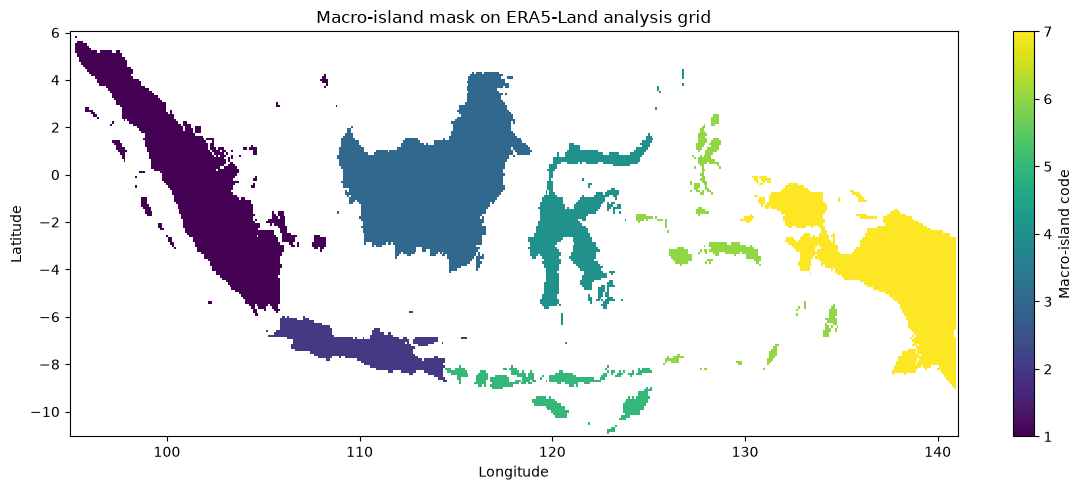

Code mapping:
1 = Sumatra
2 = Jawa
3 = Kalimantan
4 = Sulawesi
5 = Bali-Nusa Tenggara
6 = Maluku
7 = Papua


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_data = island_code.where(
    island_code > 0
)

mesh = ax.pcolormesh(
    longitude,
    latitude,
    plot_data,
    shading="auto",
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    label="Macro-island code",
)

ax.set(
    xlabel="Longitude",
    ylabel="Latitude",
    title="Macro-island mask on ERA5-Land analysis grid",
)

fig.tight_layout()

if SAVE_PNG:
    fig.savefig(
        OUTPUT_DIR / "figure_macro_island_mask.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

if SAVE_PDF:
    fig.savefig(
        OUTPUT_DIR / "figure_macro_island_mask.pdf",
        bbox_inches="tight",
    )

plt.show()

print("Code mapping:")
for n, name in zip(island_numbers, island_names):
    print(f"{n} = {name}")


## 13. Buka dataset FD M0–M3


In [13]:
datasets = {}

for method, path in method_files.items():
    ds = xr.open_dataset(
        path,
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        mask_and_scale=False,
    )

    required = {
        "fd_event_start",
        "fd_drought_core",
    }

    missing = required.difference(
        ds.data_vars
    )

    if missing:
        raise KeyError(
            f"{method} kehilangan variabel {sorted(missing)}"
        )

    datasets[method] = ds

    print(
        method,
        "->",
        path.name,
        dict(ds.sizes),
    )


M0 -> fd_detection_M0_1995_2025_indonesia_masked.nc {'time_index': 2263, 'latitude': 171, 'longitude': 461}
M1 -> fd_detection_M1_1995_2025_indonesia.nc {'time_index': 2263, 'latitude': 171, 'longitude': 461}


C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 20. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 20. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at inde

M2A -> fd_detection_M2A_1995_2025_indonesia.nc {'time_index': 2263, 'latitude': 171, 'longitude': 461}
M2B -> fd_detection_M2B_1995_2025_indonesia.nc {'time_index': 2263, 'latitude': 171, 'longitude': 461}
M3 -> fd_detection_M3_1995_2025_indonesia.nc {'time_index': 2263, 'latitude': 171, 'longitude': 461}


C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 20. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 20. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_17728\2389294603.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at inde

## 14. Validasi waktu


In [14]:
reference = datasets[PRIMARY_METHOD]

for coord in ["year", "pentad"]:
    if coord not in reference.coords:
        raise KeyError(
            f"Koordinat {coord!r} tidak ada pada dataset primary method {PRIMARY_METHOD}."
        )

year_of_step = (
    reference["year"].values.astype(int)
)

pentad_of_step = (
    reference["pentad"].values.astype(int)
)

for method, ds in datasets.items():
    if not np.array_equal(
        ds["year"].values.astype(int),
        year_of_step,
    ):
        raise ValueError(
            f"Koordinat year {method} tidak konsisten."
        )

    if not np.array_equal(
        ds["pentad"].values.astype(int),
        pentad_of_step,
    ):
        raise ValueError(
            f"Koordinat pentad {method} tidak konsisten."
        )

print(
    "Time steps:",
    len(year_of_step),
    "|",
    (year_of_step[0], pentad_of_step[0]),
    "s.d.",
    (year_of_step[-1], pentad_of_step[-1]),
)


Time steps: 2263 | (np.int64(1995), np.int64(1)) s.d. (np.int64(2025), np.int64(73))


## 15. Fungsi statistik FD per pulau


In [15]:
def get_region_mask_and_weight(island_name):
    mask = (
        island_valid_grid_mask
        .sel(island=island_name)
        .astype(bool)
    )

    weights = weight_2d.where(mask)
    total_weight = float(weights.sum())

    if total_weight <= 0:
        raise RuntimeError(
            f"Bobot area nol untuk {island_name}."
        )

    return mask, weights, total_weight


def weighted_area_percent(
    flag,
    mask,
    weights,
    total_weight,
):
    active = (
        (flag == 1)
        .where(mask, False)
    )

    area = (
        active * weights
    ).sum(
        ("latitude", "longitude")
    )

    return 100.0 * area / total_weight


def compute_island_timeseries(
    method,
    ds,
):
    frames = []

    for island_name in island_names:
        mask, weights, total_weight = (
            get_region_mask_and_weight(
                island_name
            )
        )

        onset_area = weighted_area_percent(
            ds["fd_event_start"],
            mask,
            weights,
            total_weight,
        )

        core_area = weighted_area_percent(
            ds["fd_drought_core"],
            mask,
            weights,
            total_weight,
        )

        start_count = (
            (ds["fd_event_start"] == 1)
            .where(mask, False)
            .sum(("latitude", "longitude"))
        )

        work = xr.Dataset({
            "new_onset_area_percent": onset_area,
            "drought_core_area_percent": core_area,
            "event_start_grid_count": start_count,
        }).compute()

        df = work.to_dataframe().reset_index()

        df["method"] = method
        df["island"] = island_name

        if "year" not in df.columns:
            df["year"] = (
                year_of_step[
                    df["time_index"].astype(int)
                ]
            )

        if "pentad" not in df.columns:
            df["pentad"] = (
                pentad_of_step[
                    df["time_index"].astype(int)
                ]
            )

        frames.append(
            df[[
                "method",
                "island",
                "time_index",
                "year",
                "pentad",
                "new_onset_area_percent",
                "drought_core_area_percent",
                "event_start_grid_count",
            ]]
        )

    return pd.concat(
        frames,
        ignore_index=True,
    )


## 16. Hitung metrik pentad semua metode


In [16]:
parts = []

for method in METHODS:
    print("Menghitung regional summary:", method)

    parts.append(
        compute_island_timeseries(
            method,
            datasets[method],
        )
    )

island_pentad_metrics = pd.concat(
    parts,
    ignore_index=True,
)

PENTAD_FILE = (
    OUTPUT_DIR
    / "fd_island_pentad_metrics_1995_2025.csv"
)

island_pentad_metrics.to_csv(
    PENTAD_FILE,
    index=False,
)

print("Tersimpan:", PENTAD_FILE)
display(island_pentad_metrics.head())


Menghitung regional summary: M0
Menghitung regional summary: M1
Menghitung regional summary: M2A
Menghitung regional summary: M2B
Menghitung regional summary: M3
Tersimpan: D:\ERA5_LAND\output_fd_03c_island_M2A\fd_island_pentad_metrics_1995_2025.csv


,method,island,time_index,year,pentad,new_onset_area_percent,drought_core_area_percent,event_start_grid_count
0,M0,Sumatra,0,1995,1,0.374838,0.000000,14
1,M0,Sumatra,1,1995,2,0.348223,0.053551,13
2,M0,Sumatra,2,1995,3,1.312621,0.267735,49
3,M0,Sumatra,3,1995,4,0.294395,0.723052,11
4,M0,Sumatra,4,1995,5,0.293992,1.017333,11


## 17. Agregasi tahunan


In [17]:
annual_rows = []

for (
    method,
    island,
    year,
), group in island_pentad_metrics.groupby(
    ["method", "island", "year"],
    sort=True,
):
    group = group.sort_values("pentad")

    core_peak_idx = (
        group[
            "drought_core_area_percent"
        ].idxmax()
    )

    onset_peak_idx = (
        group[
            "new_onset_area_percent"
        ].idxmax()
    )

    annual_rows.append({
        "method": method,
        "island": island,
        "year": int(year),
        "ranking_eligible": (
            int(year)
            not in RANKING_EXCLUDE_YEARS
        ),
        "grid_cell_event_starts": int(
            group[
                "event_start_grid_count"
            ].sum()
        ),
        "maximum_new_onset_area_percent": float(
            group[
                "new_onset_area_percent"
            ].max()
        ),
        "peak_new_onset_pentad": int(
            island_pentad_metrics.loc[
                onset_peak_idx,
                "pentad",
            ]
        ),
        "maximum_drought_core_area_percent": float(
            group[
                "drought_core_area_percent"
            ].max()
        ),
        "peak_drought_core_pentad": int(
            island_pentad_metrics.loc[
                core_peak_idx,
                "pentad",
            ]
        ),
        "integrated_drought_core_area_pentad_percent": float(
            group[
                "drought_core_area_percent"
            ].sum()
        ),
        "mean_drought_core_area_percent": float(
            group[
                "drought_core_area_percent"
            ].mean()
        ),
    })

island_annual_metrics = pd.DataFrame(
    annual_rows
)

ANNUAL_FILE = (
    OUTPUT_DIR
    / "fd_island_annual_metrics_1995_2025.csv"
)

island_annual_metrics.to_csv(
    ANNUAL_FILE,
    index=False,
)

print("Tersimpan:", ANNUAL_FILE)


Tersimpan: D:\ERA5_LAND\output_fd_03c_island_M2A\fd_island_annual_metrics_1995_2025.csv


## 18. Top-10 tahun M2A per pulau


In [18]:
m1_rank = island_annual_metrics[
    (island_annual_metrics["method"] == PRIMARY_METHOD)
    & island_annual_metrics["ranking_eligible"]
].copy()

m1_rank["island_rank"] = (
    m1_rank.groupby("island")[
        "maximum_drought_core_area_percent"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

m1_rank = m1_rank.sort_values(
    ["island", "island_rank"]
)

PRIMARY_RANK_FILE = (
    OUTPUT_DIR
    / "fd_M2A_top_years_by_island.csv"
)

m1_rank.to_csv(
    PRIMARY_RANK_FILE,
    index=False,
)

display(
    m1_rank[
        m1_rank["island_rank"] <= 10
    ][[
        "island",
        "island_rank",
        "year",
        "maximum_drought_core_area_percent",
        "peak_drought_core_pentad",
        "maximum_new_onset_area_percent",
        "integrated_drought_core_area_pentad_percent",
    ]]
)


,island,island_rank,year,maximum_drought_core_area_percent,peak_drought_core_pentad,maximum_new_onset_area_percent,integrated_drought_core_area_pentad_percent
436,Bali-Nusa Tenggara,1,1997,90.209124,19,38.398506,3905.612849
451,Bali-Nusa Tenggara,2,2012,70.055572,22,33.185535,483.505895
440,Bali-Nusa Tenggara,3,2001,69.875989,13,27.831152,419.498192
456,Bali-Nusa Tenggara,4,2017,67.009773,13,29.573512,350.817436
443,Bali-Nusa Tenggara,5,2004,61.816769,24,24.148342,985.409596
...,...,...,...,...,...,...,...
621,Sumatra,6,1996,70.169990,28,45.450452,766.123677
640,Sumatra,7,2015,66.822765,38,28.886267,1406.484816
634,Sumatra,8,2009,63.226094,24,36.556984,693.401617
624,Sumatra,9,1999,61.214220,24,15.315909,544.837240


## 19. Robustness M0–M3 per pulau


In [19]:
eligible = island_annual_metrics[
    island_annual_metrics["ranking_eligible"]
].copy()

robust_rows = []

for island_name in island_names:
    top_sets = {}

    for method in METHODS:
        top = (
            eligible[
                (eligible["island"] == island_name)
                & (eligible["method"] == method)
            ]
            .nlargest(
                ROBUST_TOP_N,
                "maximum_drought_core_area_percent",
            )
        )

        top_sets[method] = set(
            top["year"].astype(int)
        )

    common = set.intersection(
        *top_sets.values()
    )

    years_to_report = sorted(
        set(CASE_YEARS) | common
    )

    for year in years_to_report:
        row = {
            "island": island_name,
            "year": int(year),
            "in_all_method_top5": (
                year in common
            ),
        }

        for method in METHODS:
            row[
                f"in_{method}_top5"
            ] = (
                year
                in top_sets[method]
            )

        robust_rows.append(row)

island_robustness = pd.DataFrame(
    robust_rows
)

ROBUST_FILE = (
    OUTPUT_DIR
    / "fd_case_year_robustness_by_island.csv"
)

island_robustness.to_csv(
    ROBUST_FILE,
    index=False,
)

display(
    island_robustness[
        island_robustness["year"].isin(
            CASE_YEARS
        )
    ]
)


,island,year,in_all_method_top5,in_M0_top5,in_M1_top5,in_M2A_top5,in_M2B_top5,in_M3_top5
0,Sumatra,1997,True,True,True,True,True,True
1,Sumatra,2003,True,True,True,True,True,True
2,Sumatra,2004,False,False,False,False,False,False
4,Sumatra,2014,True,True,True,True,True,True
5,Sumatra,2015,False,False,False,False,False,False
7,Jawa,1997,True,True,True,True,True,True
8,Jawa,2003,True,True,True,True,True,True
9,Jawa,2004,False,False,False,False,False,False
10,Jawa,2014,False,False,False,False,False,False
11,Jawa,2015,False,False,False,False,False,False


## 20. Climatological timing M2A per pulau


In [20]:
m1_pentad = island_pentad_metrics[
    (island_pentad_metrics["method"] == PRIMARY_METHOD)
    & (~island_pentad_metrics["year"].isin(
        RANKING_EXCLUDE_YEARS
    ))
].copy()

climatology = (
    m1_pentad
    .groupby(
        ["island", "pentad"],
        as_index=False,
    )
    .agg(
        mean_new_onset_area_percent=(
            "new_onset_area_percent",
            "mean",
        ),
        mean_drought_core_area_percent=(
            "drought_core_area_percent",
            "mean",
        ),
        median_new_onset_area_percent=(
            "new_onset_area_percent",
            "median",
        ),
        mean_event_start_grid_count=(
            "event_start_grid_count",
            "mean",
        ),
    )
)

base = pd.Timestamp("2001-01-01")

pentad_center_date = {
    p: (
        base
        + pd.Timedelta(
            days=(p - 1) * 5 + 2
        )
    )
    for p in range(1, 74)
}

climatology["approx_month"] = (
    climatology["pentad"].map(
        lambda p: pentad_center_date[
            int(p)
        ].strftime("%b")
    )
)

CLIM_FILE = (
    OUTPUT_DIR
    / "fd_M2A_climatological_pentad_by_island.csv"
)

climatology.to_csv(
    CLIM_FILE,
    index=False,
)

peak_rows = []

for island_name, group in climatology.groupby(
    "island"
):
    onset_row = group.loc[
        group[
            "mean_new_onset_area_percent"
        ].idxmax()
    ]

    core_row = group.loc[
        group[
            "mean_drought_core_area_percent"
        ].idxmax()
    ]

    peak_rows.append({
        "island": island_name,
        "peak_onset_pentad": int(
            onset_row["pentad"]
        ),
        "peak_onset_month": (
            onset_row["approx_month"]
        ),
        "peak_core_pentad": int(
            core_row["pentad"]
        ),
        "peak_core_month": (
            core_row["approx_month"]
        ),
    })

seasonal_peaks = pd.DataFrame(
    peak_rows
)

seasonal_peaks.to_csv(
    OUTPUT_DIR
    / "fd_M2A_peak_timing_by_island.csv",
    index=False,
)

display(seasonal_peaks)


,island,peak_onset_pentad,peak_onset_month,peak_core_pentad,peak_core_month
0,Bali-Nusa Tenggara,14,Mar,18,Mar
1,Jawa,1,Jan,28,May
2,Kalimantan,26,May,30,May
3,Maluku,36,Jun,38,Jul
4,Papua,28,May,30,May
5,Sulawesi,26,May,31,Jun
6,Sumatra,23,Apr,29,May


## 21. Kandidat tahun: pulau dominan


In [21]:
case_summary = island_annual_metrics[
    (island_annual_metrics["method"] == PRIMARY_METHOD)
    & island_annual_metrics["year"].isin(
        CASE_YEARS
    )
].copy()

case_summary["within_year_rank_by_peak_core"] = (
    case_summary.groupby("year")[
        "maximum_drought_core_area_percent"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

CASE_FILE = (
    OUTPUT_DIR
    / "fd_M2A_case_years_island_summary.csv"
)

case_summary.to_csv(
    CASE_FILE,
    index=False,
)

display(
    case_summary.sort_values(
        [
            "year",
            "within_year_rank_by_peak_core",
        ]
    )[[
        "year",
        "island",
        "within_year_rank_by_peak_core",
        "maximum_drought_core_area_percent",
        "peak_drought_core_pentad",
        "maximum_new_onset_area_percent",
        "integrated_drought_core_area_pentad_percent",
    ]]
)


,year,island,within_year_rank_by_peak_core,maximum_drought_core_area_percent,peak_drought_core_pentad,maximum_new_onset_area_percent,integrated_drought_core_area_pentad_percent
436,1997,Bali-Nusa Tenggara,1,90.209124,19,38.398506,3905.612849
467,1997,Jawa,2,84.370739,18,48.679232,1481.297442
498,1997,Kalimantan,3,79.663782,32,32.732891,2385.853219
560,1997,Papua,4,79.498267,32,38.097201,2950.172928
529,1997,Maluku,5,77.228431,32,46.537777,3170.101982
622,1997,Sumatra,6,70.814055,33,29.292265,2322.303318
591,1997,Sulawesi,7,60.045032,34,21.419173,2453.726344
628,2003,Sumatra,1,97.244672,32,53.750002,1330.711034
597,2003,Sulawesi,2,93.638028,34,43.969587,1019.302181
504,2003,Kalimantan,3,92.828782,32,44.280668,1121.955480


## 22. National M2A peak pentad dan synchronized island summary

Bagian ini memperbaiki kelemahan `within_year_rank_by_peak_core`.

Untuk setiap tahun kasus:

1. hitung **maximum national M1 drought-core area** dalam tahun tersebut;
2. ambil `time_index` puncak nasional;
3. pada **time_index yang sama**, hitung drought-core area setiap pulau;
4. hitung juga statistik dalam window **±2 pentad** menggunakan timeline kontinu.

Dengan cara ini, pulau tidak dibandingkan menggunakan maksimum tahunan yang terjadi
pada waktu berbeda.

Window memakai `time_index`, bukan memotong berdasarkan Januari–Desember. Karena itu,
jika puncak berada dekat P1 atau P73, window dapat melewati batas tahun.


In [22]:
def national_weighted_area_percent(flag):
    mask = valid_grid
    weights = weight_2d.where(mask)
    total_weight = float(weights.sum())

    active = (flag == 1).where(mask, False)
    numerator = (active * weights).sum(("latitude", "longitude"))
    return 100.0 * numerator / total_weight


m1_ds = datasets[PRIMARY_METHOD]

national_m1_core = national_weighted_area_percent(
    m1_ds["fd_drought_core"]
).compute()

national_m1_onset = national_weighted_area_percent(
    m1_ds["fd_event_start"]
).compute()

national_m1_timeseries = pd.DataFrame({
    "time_index": np.arange(m1_ds.sizes["time_index"], dtype=int),
    "year": year_of_step,
    "pentad": pentad_of_step,
    "national_drought_core_area_percent": national_m1_core.values.astype(float),
    "national_new_onset_area_percent": national_m1_onset.values.astype(float),
})

NATIONAL_TS_FILE = (
    OUTPUT_DIR / "fd_M2A_national_pentad_metrics_1995_2025.csv"
)
national_m1_timeseries.to_csv(NATIONAL_TS_FILE, index=False)

national_peak_rows = []

for selected_year in CASE_YEARS:
    year_subset = national_m1_timeseries[
        national_m1_timeseries["year"] == selected_year
    ].copy()

    if year_subset.empty:
        continue

    peak_row = year_subset.loc[
        year_subset["national_drought_core_area_percent"].idxmax()
    ]

    national_peak_rows.append({
        "year": int(selected_year),
        "case_class": (
            "robust_national_case"
            if selected_year in MAIN_CASE_YEARS
            else "regional_sensitivity_case"
        ),
        "national_peak_time_index": int(peak_row["time_index"]),
        "national_peak_pentad": int(peak_row["pentad"]),
        "national_peak_drought_core_area_percent": float(
            peak_row["national_drought_core_area_percent"]
        ),
        "national_new_onset_area_at_peak_percent": float(
            peak_row["national_new_onset_area_percent"]
        ),
    })

national_case_peaks = pd.DataFrame(national_peak_rows)

NATIONAL_PEAK_FILE = (
    OUTPUT_DIR / "fd_M2A_case_year_national_peak_pentads.csv"
)
national_case_peaks.to_csv(NATIONAL_PEAK_FILE, index=False)

display(national_case_peaks)


,year,case_class,national_peak_time_index,national_peak_pentad,national_peak_drought_core_area_percent,national_new_onset_area_at_peak_percent
0,2003,robust_national_case,616,33,81.419568,1.441539
1,1997,robust_national_case,177,32,69.897383,0.645233
2,2015,robust_national_case,1498,39,69.548994,0.168402
3,2014,robust_national_case,1394,8,55.171887,0.590107
4,2004,regional_sensitivity_case,692,36,48.140909,0.000000


In [23]:
sync_rows = []
window_rows = []

# Lookup pulau pada time_index yang sama.
m1_island_lookup = (
    island_pentad_metrics[
        island_pentad_metrics["method"] == PRIMARY_METHOD
    ]
    .set_index(["island", "time_index"])
    .sort_index()
)

n_time = len(year_of_step)

for peak in national_case_peaks.itertuples(index=False):
    peak_t = int(peak.national_peak_time_index)

    # EXACT national peak
    for island_name in island_names:
        record = m1_island_lookup.loc[(island_name, peak_t)]

        sync_rows.append({
            "year": int(peak.year),
            "case_class": peak.case_class,
            "national_peak_time_index": peak_t,
            "national_peak_pentad": int(peak.national_peak_pentad),
            "national_peak_drought_core_area_percent": float(
                peak.national_peak_drought_core_area_percent
            ),
            "island": island_name,
            "island_drought_core_area_at_national_peak_percent": float(
                record["drought_core_area_percent"]
            ),
            "island_new_onset_area_at_national_peak_percent": float(
                record["new_onset_area_percent"]
            ),
        })

    # ±2 pentad GLOBAL time_index window
    left = max(0, peak_t - NATIONAL_PEAK_WINDOW_RADIUS)
    right = min(n_time - 1, peak_t + NATIONAL_PEAK_WINDOW_RADIUS)

    window_indices = np.arange(left, right + 1, dtype=int)

    for t in window_indices:
        actual_year = int(year_of_step[t])
        actual_pentad = int(pentad_of_step[t])

        for island_name in island_names:
            record = m1_island_lookup.loc[(island_name, t)]

            window_rows.append({
                "case_year": int(peak.year),
                "case_class": peak.case_class,
                "national_peak_time_index": peak_t,
                "national_peak_pentad": int(peak.national_peak_pentad),
                "relative_pentad": int(t - peak_t),
                "time_index": int(t),
                "actual_year": actual_year,
                "actual_pentad": actual_pentad,
                "island": island_name,
                "drought_core_area_percent": float(
                    record["drought_core_area_percent"]
                ),
                "new_onset_area_percent": float(
                    record["new_onset_area_percent"]
                ),
            })

synchronized_peak_summary = pd.DataFrame(sync_rows)
synchronized_peak_window = pd.DataFrame(window_rows)

SYNC_FILE = (
    OUTPUT_DIR / "fd_M2A_island_summary_at_national_peak.csv"
)
SYNC_WINDOW_FILE = (
    OUTPUT_DIR / "fd_M2A_island_summary_national_peak_window_pm2.csv"
)

synchronized_peak_summary.to_csv(SYNC_FILE, index=False)
synchronized_peak_window.to_csv(SYNC_WINDOW_FILE, index=False)

display(
    synchronized_peak_summary.sort_values(
        ["year", "island_drought_core_area_at_national_peak_percent"],
        ascending=[True, False],
    )
)


,year,case_class,national_peak_time_index,national_peak_pentad,national_peak_drought_core_area_percent,island,island_drought_core_area_at_national_peak_percent,island_new_onset_area_at_national_peak_percent
9,1997,robust_national_case,177,32,69.897383,Kalimantan,79.663782,0.000000
13,1997,robust_national_case,177,32,69.897383,Papua,79.498267,0.000000
12,1997,robust_national_case,177,32,69.897383,Maluku,77.228431,0.000000
11,1997,robust_national_case,177,32,69.897383,Bali-Nusa Tenggara,70.610360,0.000000
7,1997,robust_national_case,177,32,69.897383,Sumatra,69.963201,2.057918
10,1997,robust_national_case,177,32,69.897383,Sulawesi,59.485261,0.000000
8,1997,robust_national_case,177,32,69.897383,Jawa,9.056913,1.834500
0,2003,robust_national_case,616,33,81.419568,Sumatra,96.334963,0.000000
3,2003,robust_national_case,616,33,81.419568,Sulawesi,93.428042,0.000000
2,2003,robust_national_case,616,33,81.419568,Kalimantan,92.805400,0.000000


## 23. Heatmap — annual maximum drought-core M2A

Menggantikan grafik 7 garis × ~29 tahun.

- sumbu-X: tahun;
- sumbu-Y: macro-island;
- warna: annual maximum drought-core area (% dari area pulau).

Heatmap ini menunjukkan apakah satu tahun kuat pada banyak pulau atau hanya regional.


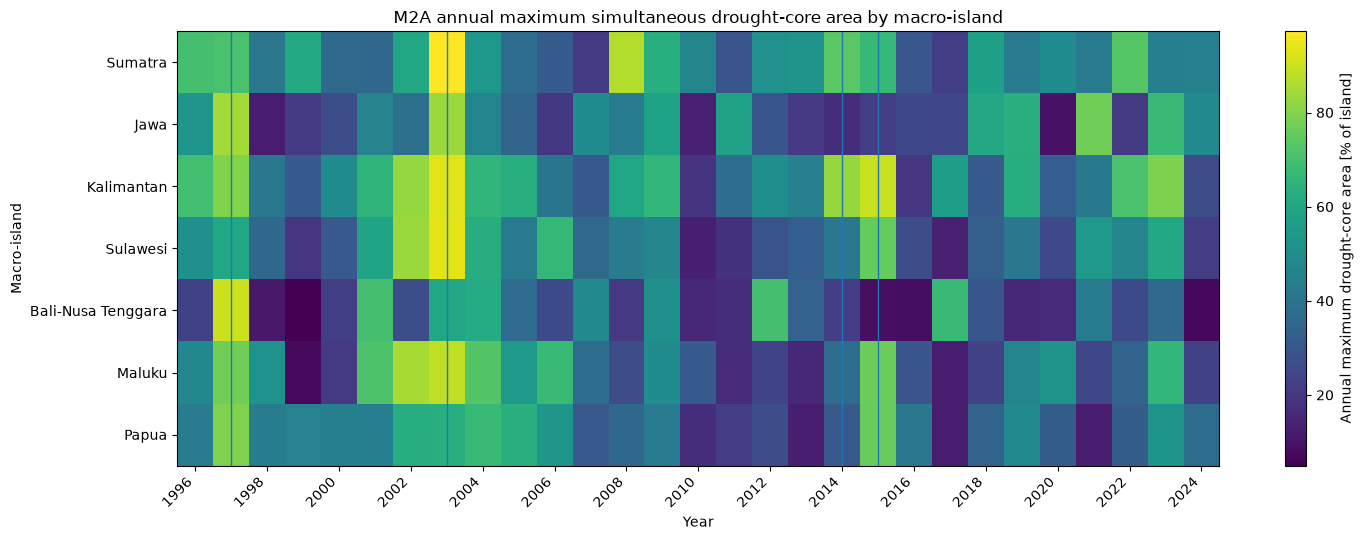

In [24]:
annual_heatmap_data = (
    island_annual_metrics[
        (island_annual_metrics["method"] == PRIMARY_METHOD)
        & island_annual_metrics["ranking_eligible"]
    ]
    .pivot(
        index="island",
        columns="year",
        values="maximum_drought_core_area_percent",
    )
    .reindex(island_names)
)

fig, ax = plt.subplots(figsize=(15, 5.5))

im = ax.imshow(
    annual_heatmap_data.values,
    aspect="auto",
    interpolation="nearest",
)

ax.set_yticks(np.arange(len(island_names)))
ax.set_yticklabels(island_names)

years = annual_heatmap_data.columns.to_numpy(dtype=int)
tick_positions = np.arange(0, len(years), 2)
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    years[tick_positions],
    rotation=45,
    ha="right",
)

# Mark important case years if present.
for case_year in MAIN_CASE_YEARS:
    matches = np.where(years == case_year)[0]
    if matches.size:
        ax.axvline(matches[0], linewidth=1)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Annual maximum drought-core area [% of island]")

ax.set(
    xlabel="Year",
    ylabel="Macro-island",
    title="M2A annual maximum simultaneous drought-core area by macro-island",
)

fig.tight_layout()

if SAVE_PNG:
    fig.savefig(
        OUTPUT_DIR / "heatmap_M2A_annual_max_core_year_island.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

if SAVE_PDF:
    fig.savefig(
        OUTPUT_DIR / "heatmap_M2A_annual_max_core_year_island.pdf",
        bbox_inches="tight",
    )

plt.show()


## 24. Heatmap — climatological timing M2A

Menggantikan 7 garis climatological onset.

Warna menunjukkan rata-rata area onset FD per pulau untuk setiap pentad kalender.
Ini adalah ringkasan timing regional, **bukan redefinisi climatology RZSM**.


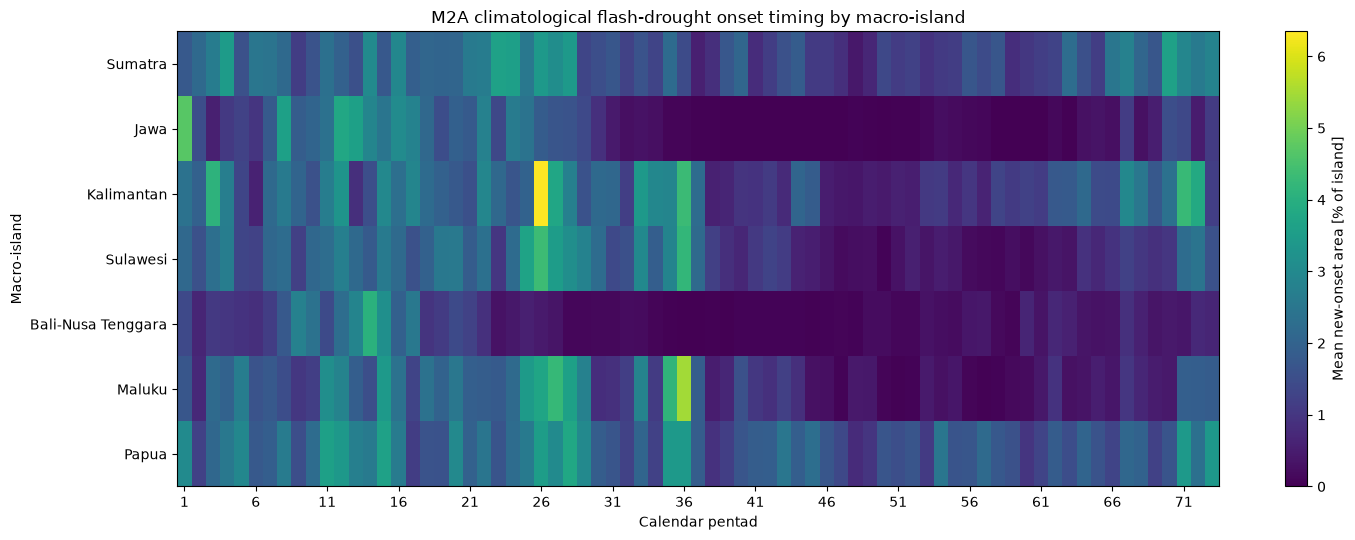

In [25]:
clim_heatmap = (
    climatology
    .pivot(
        index="island",
        columns="pentad",
        values="mean_new_onset_area_percent",
    )
    .reindex(island_names)
)

fig, ax = plt.subplots(figsize=(15, 5.5))

im = ax.imshow(
    clim_heatmap.values,
    aspect="auto",
    interpolation="nearest",
)

ax.set_yticks(np.arange(len(island_names)))
ax.set_yticklabels(island_names)

pentads = clim_heatmap.columns.to_numpy(dtype=int)
tick_positions = np.arange(0, len(pentads), 5)
ax.set_xticks(tick_positions)
ax.set_xticklabels(pentads[tick_positions])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean new-onset area [% of island]")

ax.set(
    xlabel="Calendar pentad",
    ylabel="Macro-island",
    title="M2A climatological flash-drought onset timing by macro-island",
)

fig.tight_layout()

if SAVE_PNG:
    fig.savefig(
        OUTPUT_DIR / "heatmap_M2A_climatological_onset_pentad_island.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

if SAVE_PDF:
    fig.savefig(
        OUTPUT_DIR / "heatmap_M2A_climatological_onset_pentad_island.pdf",
        bbox_inches="tight",
    )

plt.show()


## 25. Heatmap — robustness score 0–5

Untuk setiap pulau dan tahun kandidat:

`robustness_score = jumlah metode (M0, M1, M2A, M2B, M3) yang menempatkan tahun tersebut dalam Top-5`.

- **5** = Top-5 pada seluruh definisi;
- **0** = tidak Top-5 pada definisi mana pun.

Ini menggantikan tabel True/False sebagai visual utama.


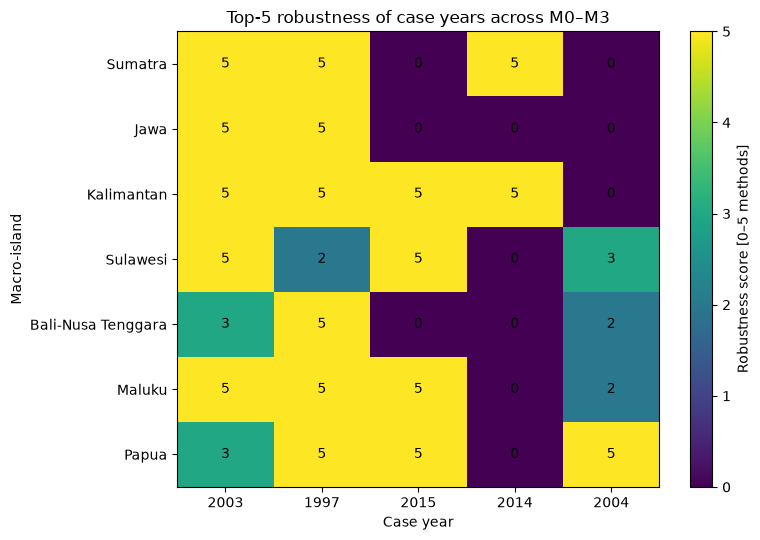

,island,year,in_all_method_top5,in_M0_top5,in_M1_top5,in_M2A_top5,in_M2B_top5,in_M3_top5,robustness_score
0,Sumatra,1997,True,True,True,True,True,True,5
7,Jawa,1997,True,True,True,True,True,True,5
14,Kalimantan,1997,True,True,True,True,True,True,5
27,Bali-Nusa Tenggara,1997,True,True,True,True,True,True,5
35,Maluku,1997,True,True,True,True,True,True,5
41,Papua,1997,True,True,True,True,True,True,5
20,Sulawesi,1997,False,False,False,False,True,True,2
1,Sumatra,2003,True,True,True,True,True,True,5
8,Jawa,2003,True,True,True,True,True,True,5
16,Kalimantan,2003,True,True,True,True,True,True,5


In [26]:
robustness_plot = (
    island_robustness[
        island_robustness["year"].isin(CASE_YEARS)
    ]
    .copy()
)

method_bool_cols = [f"in_{m}_top5" for m in METHODS]

robustness_plot["robustness_score"] = (
    robustness_plot[method_bool_cols]
    .astype(int)
    .sum(axis=1)
)

robustness_score_table = (
    robustness_plot
    .pivot(
        index="island",
        columns="year",
        values="robustness_score",
    )
    .reindex(index=island_names, columns=CASE_YEARS)
)

ROBUSTNESS_SCORE_FILE = (
    OUTPUT_DIR / "fd_case_year_robustness_score_by_island.csv"
)

robustness_plot[[
    "island",
    "year",
    "robustness_score",
    *method_bool_cols,
]].to_csv(ROBUSTNESS_SCORE_FILE, index=False)

fig, ax = plt.subplots(figsize=(8, 5.5))

im = ax.imshow(
    robustness_score_table.values,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=5,
)

ax.set_yticks(np.arange(len(island_names)))
ax.set_yticklabels(island_names)

ax.set_xticks(np.arange(len(CASE_YEARS)))
ax.set_xticklabels(CASE_YEARS)

for iy in range(len(island_names)):
    for ix in range(len(CASE_YEARS)):
        value = robustness_score_table.values[iy, ix]
        if np.isfinite(value):
            ax.text(
                ix,
                iy,
                f"{int(value)}",
                ha="center",
                va="center",
            )

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(0, 6))
cbar.set_label("Robustness score [0–5 methods]")

ax.set(
    xlabel="Case year",
    ylabel="Macro-island",
    title="Top-5 robustness of case years across M0–M3",
)

fig.tight_layout()

if SAVE_PNG:
    fig.savefig(
        OUTPUT_DIR / "heatmap_case_year_robustness_score_island.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

if SAVE_PDF:
    fig.savefig(
        OUTPUT_DIR / "heatmap_case_year_robustness_score_island.pdf",
        bbox_inches="tight",
    )

plt.show()

display(
    robustness_plot.sort_values(
        ["year", "robustness_score"],
        ascending=[True, False],
    )
)


## 26. Heatmap evolusi kasus — Pentad × Island

Untuk empat kasus nasional utama dibuat heatmap penuh 1–73.

Tahun 2004 tetap dibuat sebagai *supplementary regional/sensitivity case*.

Garis vertikal menandai **national M2A peak pentad**, sehingga variasi antar-pulau
dibaca pada event timing yang sinkron.


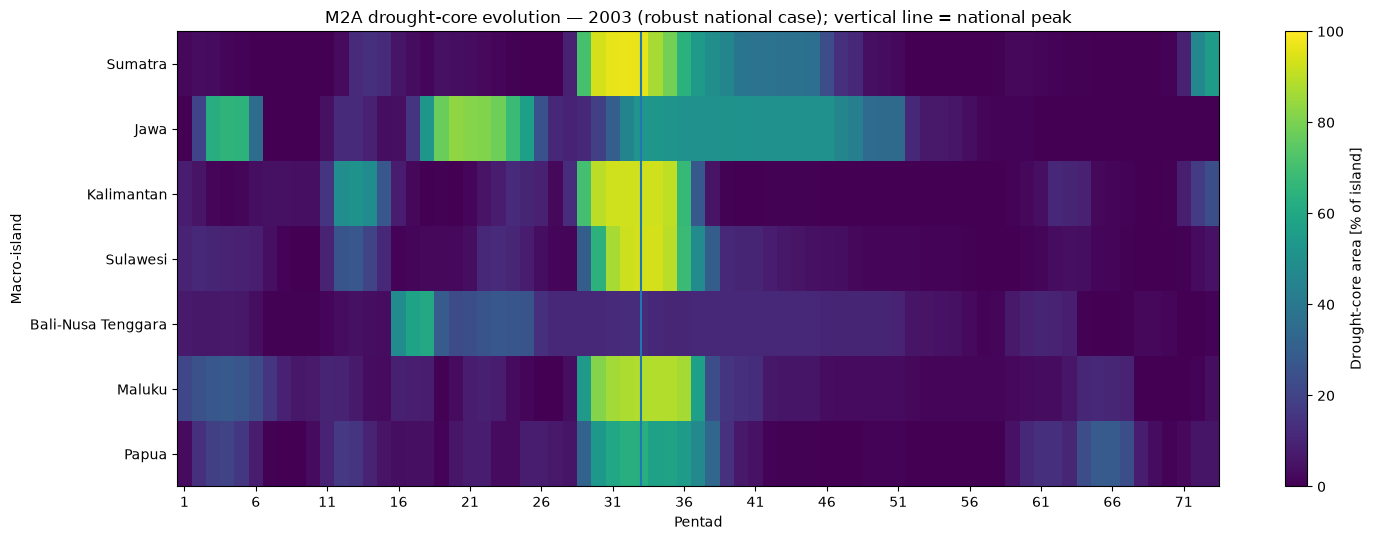

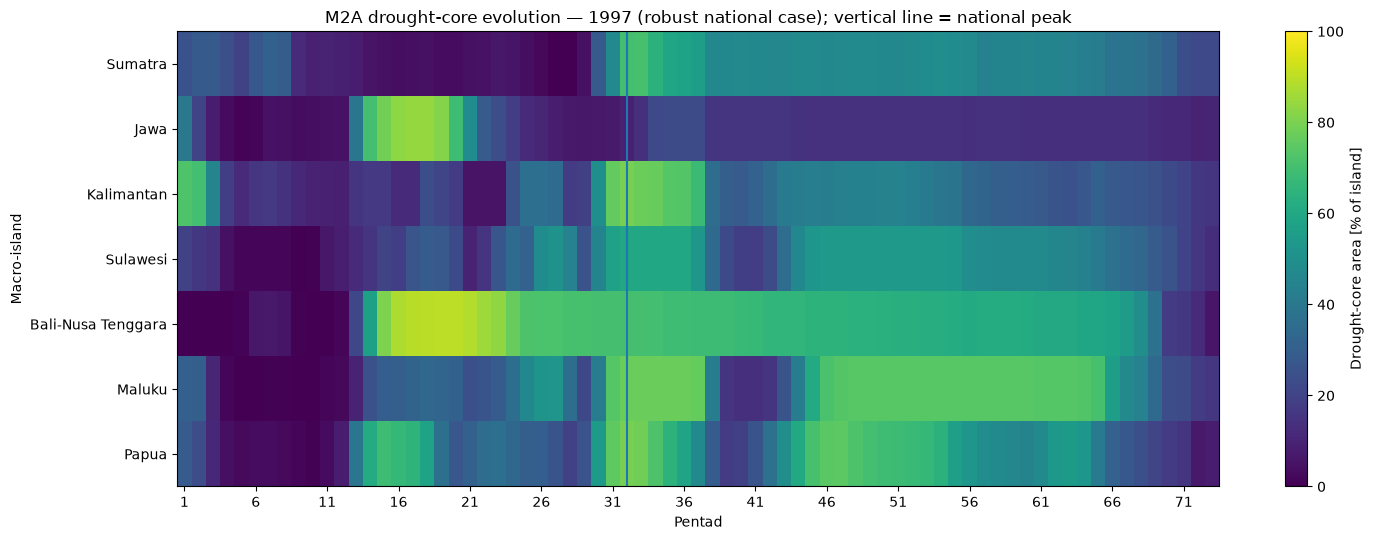

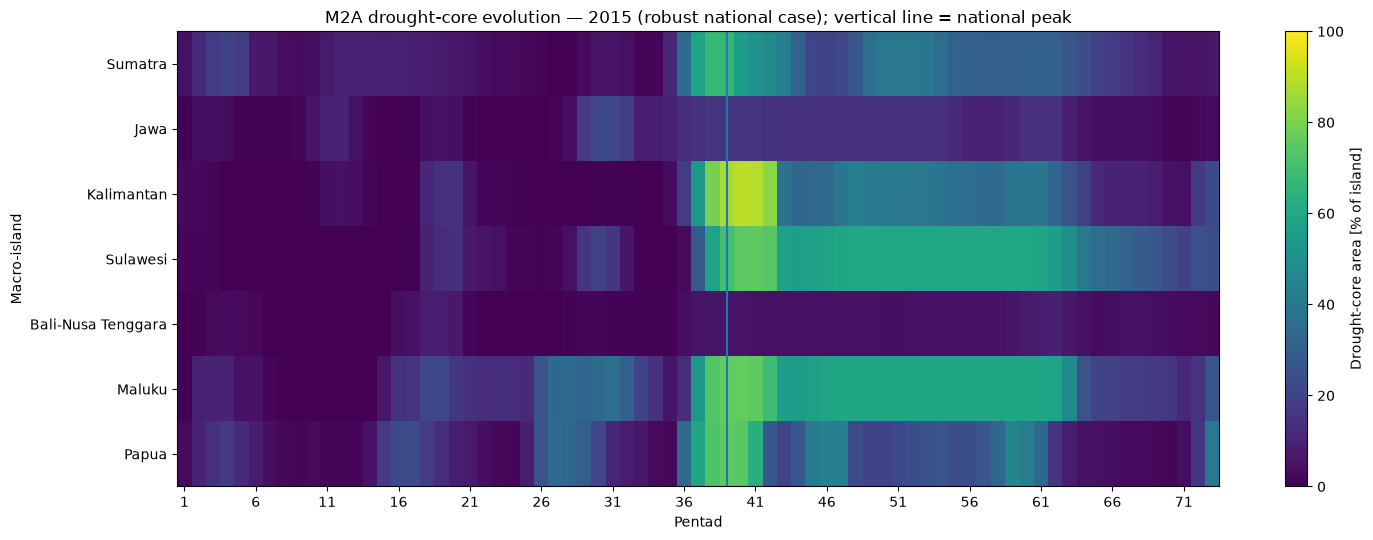

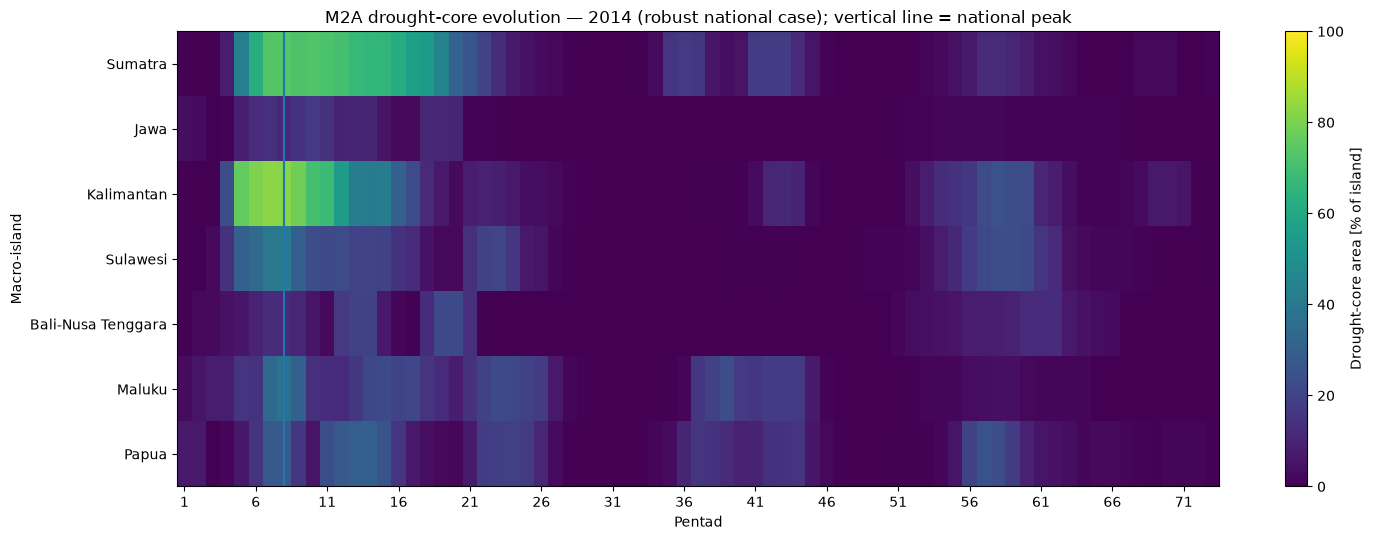

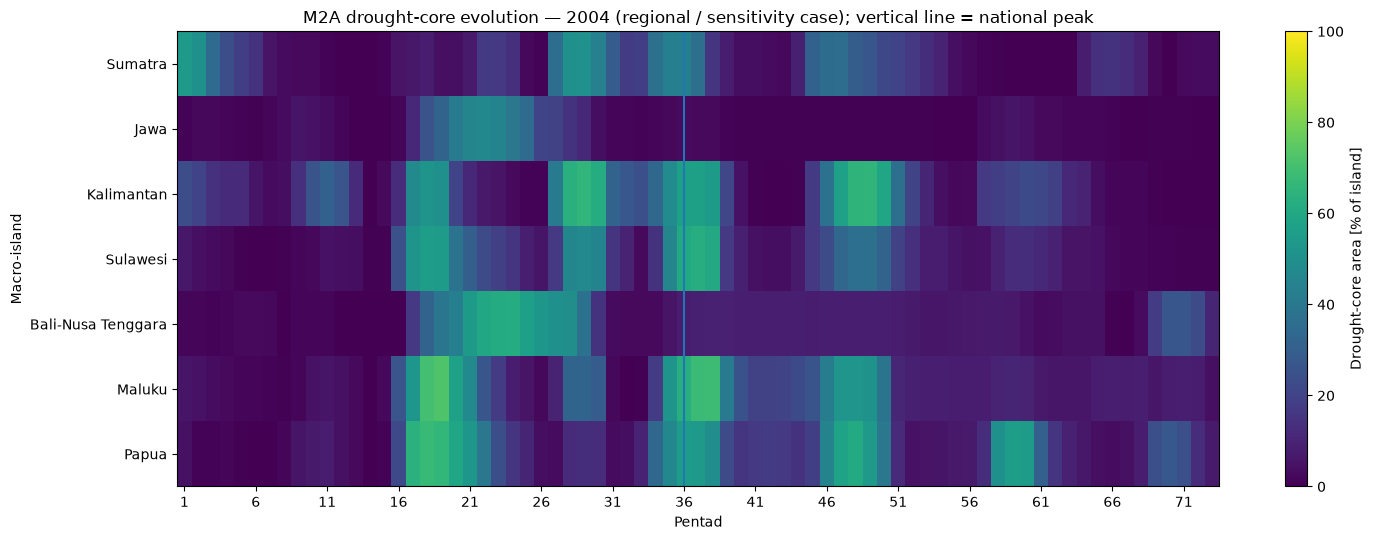

In [27]:
for selected_year in CASE_YEARS:
    subset = (
        island_pentad_metrics[
            (island_pentad_metrics["method"] == PRIMARY_METHOD)
            & (island_pentad_metrics["year"] == selected_year)
        ]
        .pivot(
            index="island",
            columns="pentad",
            values="drought_core_area_percent",
        )
        .reindex(island_names)
    )

    if subset.empty:
        continue

    peak_match = national_case_peaks[
        national_case_peaks["year"] == selected_year
    ]

    peak_pentad = (
        int(peak_match.iloc[0]["national_peak_pentad"])
        if not peak_match.empty
        else None
    )

    case_label = (
        "robust national case"
        if selected_year in MAIN_CASE_YEARS
        else "regional / sensitivity case"
    )

    fig, ax = plt.subplots(figsize=(15, 5.5))

    im = ax.imshow(
        subset.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0,
        vmax=100,
    )

    ax.set_yticks(np.arange(len(island_names)))
    ax.set_yticklabels(island_names)

    pentads = subset.columns.to_numpy(dtype=int)
    tick_positions = np.arange(0, len(pentads), 5)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(pentads[tick_positions])

    if peak_pentad is not None:
        peak_x = np.where(pentads == peak_pentad)[0]
        if peak_x.size:
            ax.axvline(
                peak_x[0],
                linewidth=1.5,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Drought-core area [% of island]")

    ax.set(
        xlabel="Pentad",
        ylabel="Macro-island",
        title=(
            f"M2A drought-core evolution — {selected_year} "
            f"({case_label}); vertical line = national peak"
        ),
    )

    fig.tight_layout()

    stem = f"heatmap_M2A_case_{selected_year}_pentad_island"

    if SAVE_PNG:
        fig.savefig(
            OUTPUT_DIR / f"{stem}.png",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    if SAVE_PDF:
        fig.savefig(
            OUTPUT_DIR / f"{stem}.pdf",
            bbox_inches="tight",
        )

    plt.show()


## 27. Heatmap synchronized national-peak window (±2 pentad)

Ini adalah visual utama untuk menjembatani 03c → 04.

Untuk setiap kasus, heatmap hanya menampilkan window ±2 pentad dari puncak nasional M2A.
Label kolom menyimpan **tahun aktual + pentad aktual**, sehingga crossing tahun tetap terlihat.

Notebook 04 sebaiknya menggunakan `time_index` dan window ini sebagai salah satu referensi
untuk diagnosis driver sinkron.


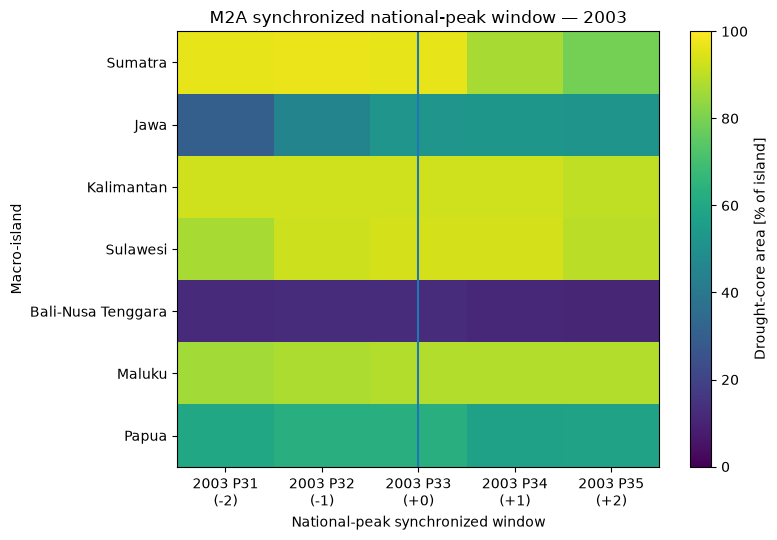

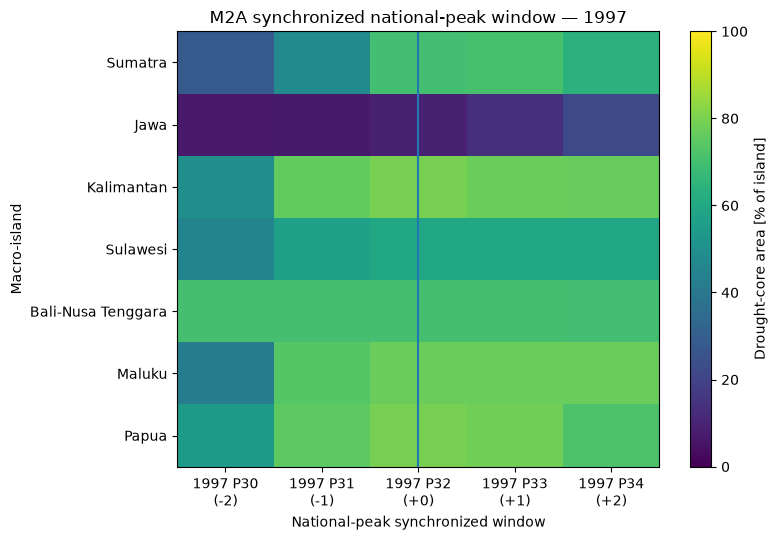

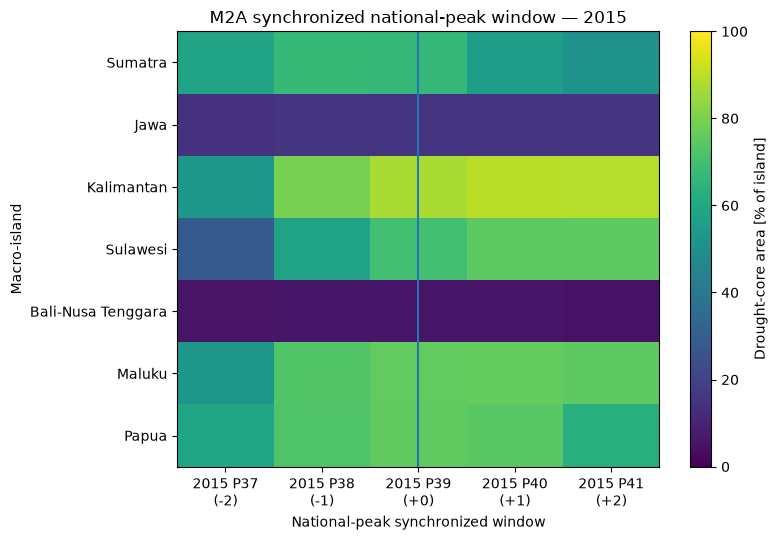

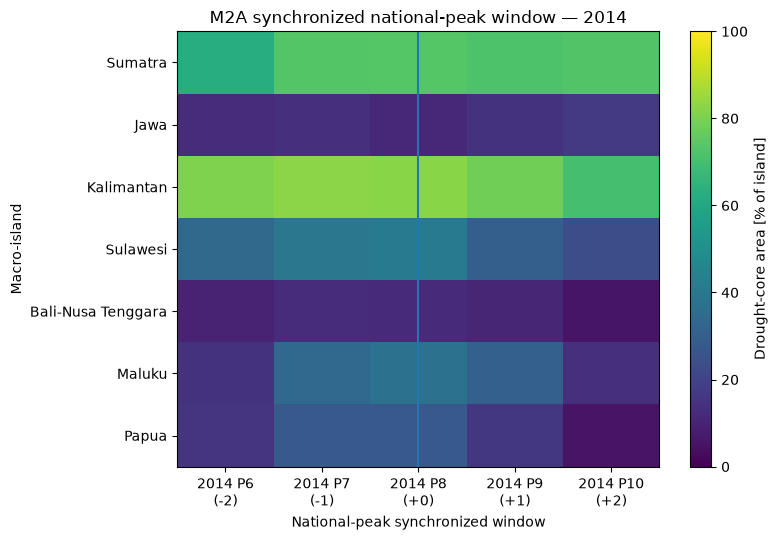

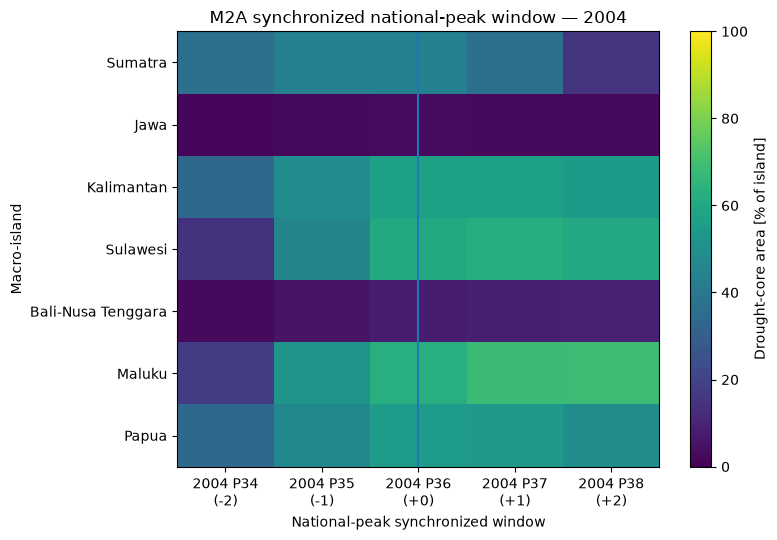

In [28]:
for selected_year in CASE_YEARS:
    window = synchronized_peak_window[
        synchronized_peak_window["case_year"] == selected_year
    ].copy()

    if window.empty:
        continue

    # Urutkan berdasarkan relative pentad.
    time_order = (
        window[[
            "relative_pentad",
            "actual_year",
            "actual_pentad",
        ]]
        .drop_duplicates()
        .sort_values("relative_pentad")
    )

    relative_order = time_order["relative_pentad"].tolist()

    heat = (
        window
        .pivot(
            index="island",
            columns="relative_pentad",
            values="drought_core_area_percent",
        )
        .reindex(index=island_names, columns=relative_order)
    )

    labels = [
        f"{int(row.actual_year)} P{int(row.actual_pentad)}\n({int(row.relative_pentad):+d})"
        for row in time_order.itertuples(index=False)
    ]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    im = ax.imshow(
        heat.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0,
        vmax=100,
    )

    ax.set_yticks(np.arange(len(island_names)))
    ax.set_yticklabels(island_names)

    ax.set_xticks(np.arange(len(relative_order)))
    ax.set_xticklabels(labels)

    peak_col = relative_order.index(0)
    ax.axvline(peak_col, linewidth=1.5)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Drought-core area [% of island]")

    ax.set(
        xlabel="National-peak synchronized window",
        ylabel="Macro-island",
        title=f"M2A synchronized national-peak window — {selected_year}",
    )

    fig.tight_layout()

    stem = f"heatmap_M2A_case_{selected_year}_national_peak_window_pm2"

    if SAVE_PNG:
        fig.savefig(
            OUTPUT_DIR / f"{stem}.png",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )

    if SAVE_PDF:
        fig.savefig(
            OUTPUT_DIR / f"{stem}.pdf",
            bbox_inches="tight",
        )

    plt.show()


## 28. Manifest untuk Notebook 04

Manifest menyimpan file mask, statistik pulau, puncak nasional, synchronized window,
dan klasifikasi kasus agar Notebook 04 tidak perlu menebak event timing kembali.


In [29]:
manifest = {
    "notebook": "03c_M2A_REGIONAL_SUMMARY_FINAL.ipynb",
    "flash_drought_redetected": False,
    "grid_resolution_changed": False,
    "primary_method": PRIMARY_METHOD,
    "primary_method_role": "adapted literature-informed FD benchmark",
    "exact_replication_of_single_published_definition": False,
    "sensitivity_methods": [
        m for m in METHODS
        if m != PRIMARY_METHOD
    ],
    "macro_islands": island_names,
    "province_boundary_file": str(PROVINCE_BOUNDARY_FILE),
    "province_name_field_detected": PROVINCE_NAME_FIELD,
    "indonesia_mask_file": str(INDONESIA_MASK_FILE),
    "method_files": {
        k: str(v)
        for k, v in method_files.items()
    },
    "ranking_exclude_years": RANKING_EXCLUDE_YEARS,
    "main_case_years": MAIN_CASE_YEARS,
    "supplementary_case_years": SUPPLEMENTARY_CASE_YEARS,
    "national_peak_window_radius_pentads": NATIONAL_PEAK_WINDOW_RADIUS,
    "unassigned_valid_grid_percent": float(unassigned_pct),
    "interpretation_notes": {
        "macro_islands_are_climate_zones": False,
        "annual_island_maxima_are_synchronized": False,
        "national_peak_summary_is_synchronized": True,
        "drought_core_area_is_single_regional_event": False,
        "case_2004_role": "regional/sensitivity comparison case",
    },
    "output_files": {
        "island_mask": str(ISLAND_MASK_FILE),
        "pentad_metrics": str(PENTAD_FILE),
        "annual_metrics": str(ANNUAL_FILE),
        "primary_M2A_rank": str(PRIMARY_RANK_FILE),
        "robustness_boolean": str(ROBUST_FILE),
        "robustness_score": str(ROBUSTNESS_SCORE_FILE),
        "climatology": str(CLIM_FILE),
        "case_summary_annual_maxima": str(CASE_FILE),
        "national_pentad_metrics": str(NATIONAL_TS_FILE),
        "case_national_peak_pentads": str(NATIONAL_PEAK_FILE),
        "island_summary_at_national_peak": str(SYNC_FILE),
        "national_peak_window_pm2": str(SYNC_WINDOW_FILE),
    },
    "created_utc": str(pd.Timestamp.now(tz="UTC")),
}

MANIFEST_FILE = (
    OUTPUT_DIR / "fd_island_summary_manifest_03c_FINAL.json"
)

with MANIFEST_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Manifest:", MANIFEST_FILE)


Manifest: D:\ERA5_LAND\output_fd_03c_island_M2A\fd_island_summary_manifest_03c_FINAL.json


## 29. Selesai

Jika notebook selesai tanpa error:

- **jangan** menghitung FD ulang;
- gunakan `fd_island_masks_era5land_grid.nc` sebagai spatial mask Notebook 04;
- gunakan M2A sebagai analisis regional utama;
- gunakan synchronized national-peak summaries untuk menyamakan timing antar-pulau;
- gunakan window ±2 pentad secara kontinu, termasuk bila melewati tahun;
- gunakan 2003, 1997, 2015, dan 2014 sebagai robust national candidate cases;
- gunakan 2004 sebagai regional/sensitivity comparison case;
- kelompok pulau tetap merupakan macro-regions geografis, bukan zona iklim homogen.


In [30]:
for ds in datasets.values():
    ds.close()

mask_ds.close()

print("=" * 70)
print("03c FINAL SELESAI")
print("=" * 70)
print("Output:", OUTPUT_DIR)
print("Next: Notebook 04 — diagnosis driver nasional dan per pulau.")
print(
    "Gunakan synchronized national-peak timing/window dari 03c "
    "agar driver dibandingkan pada event timing yang sama."
)


03c FINAL SELESAI
Output: D:\ERA5_LAND\output_fd_03c_island_M2A
Next: Notebook 04 — diagnosis driver nasional dan per pulau.
Gunakan synchronized national-peak timing/window dari 03c agar driver dibandingkan pada event timing yang sama.
